# CurtaMap — Etapa 1: EDA de fundamentos e dados

**Pergunta:** o curtailment eólico e solar observado nos dados do ONS é grande, crescente,
concentrado e recorrente o suficiente para justificar uma ferramenta de **antecipação por
usina/conjunto**? Qual causa domina e o que isso implica para o gerador?

Este notebook é o local único da EDA da Etapa 1. Ele lê os Parquet locais de `data/raw/`
com DuckDB (colunar, sem carregar as 10,8 milhões de linhas em pandas). Usa as funções
testadas de `curtamap.eda` e `curtamap.targets` e produz as tabelas e os gráficos abaixo.
Os números no texto são conferidos por `assert` na seção de verificação: se os dados mudarem,
o notebook falha em vez de exibir uma narrativa desatualizada.

**Convenções**

- **Fonte dos dados:** snapshot tratado do ONS fornecido pelo Hackathon
  (`constrained_off_eolica_tm.parquet` e `constrained_off_fotovoltaica_tm.parquet`).
- **Métrica de volume:** GNR analítica = `max(val_geracaoreferencia − val_geracao, 0)` em MWmed,
  somente quando `val_geracaolimitada` não é nulo. Energia = MWmed × 0,5 h (MWh).
  Definição em `docs/target-definition.md`.
- **Comando × corte:** `restricao_registrada` (limite não nulo, inclusive zero) é diferente
  de `corte_positivo` (volume > 0).
- **Nenhuma imputação:** linhas ausentes não viram zero. Volumes indeterminados ficam nulos e
  são contados à parte.
- Resultados são **estimativas analíticas provisórias**. Não representam liquidação CCEE,
  ressarcimento ou valor financeiro.
- Referências externas (Caderno, estudos citados) aparecem somente na seção final e são
  marcadas como **externas**.

In [1]:
import calendar
import json
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from curtamap.audit import sha256
from curtamap.data_contract import SPECS
from curtamap.eda import build_tables

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
REPORTS = ROOT / "docs" / "reports" / "stage1"
AUDIT = json.loads((REPORTS / "audit.json").read_text())
OFFICIAL = json.loads((REPORTS / "official-comparison.json").read_text())

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(".")
pl.Config.set_decimal_separator(",")

FONTE = {"eolica": "Eólica", "fotovoltaica": "Fotovoltaica"}
# Paleta categórica validada (CVD e visão normal); ordem fixa, cor segue a entidade.
COR_FONTE = {"eolica": "#2a78d6", "fotovoltaica": "#eb6834"}
COR_CAUSA = {"CNF": "#1baf7a", "ENE": "#eda100", "REL": "#e87ba4", "DESCONHECIDA": "#8a8984"}
CAUSAS = ["CNF", "ENE", "REL", "DESCONHECIDA"]
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.edgecolor": "#8a8984",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "lines.linewidth": 2,
        "legend.frameon": False,
    }
)


def meta(titulo, fonte, periodo, unidade, filtros, definicao, limitacoes):
    """Metadados obrigatórios de cada gráfico/tabela."""
    display(
        Markdown(
            f"**{titulo}**  \n"
            f"- Fonte: {fonte}  \n- Período: {periodo}  \n- Unidade: {unidade}  \n"
            f"- Filtros: {filtros}  \n- Definição: {definicao}  \n- Limitações: {limitacoes}"
        )
    )


SNAPSHOT = "Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica"

## 1. Procedência e base analítica

Antes de qualquer gráfico, conferimos se os arquivos lidos são os mesmos auditados em
`docs/reports/stage1/audit.json`, comparando o SHA-256. A base analítica é a **união das duas
bases principais**. A integrada não entra, pois é um subconjunto exato das principais sem
out/2023–mar/2024 eólico. O detail também não entra, pois soma usinas individuais que já estão
dentro dos conjuntos.

In [2]:
proveniencia = pl.DataFrame(
    [
        {
            "base": key,
            "arquivo": SPECS[key].filename,
            "linhas_auditadas": AUDIT["files"][key]["rows"],
            "inicio": AUDIT["files"][key]["keys"]["start"],
            "fim": AUDIT["files"][key]["keys"]["end"],
            "entidades": AUDIT["files"][key]["keys"]["entities"],
            "sha256_confere": sha256(RAW / SPECS[key].filename) == AUDIT["files"][key]["sha256"],
        }
        for key in ["eolica", "fotovoltaica"]
    ]
)
assert proveniencia["sha256_confere"].all(), "arquivo local difere do auditado"
proveniencia

base,arquivo,linhas_auditadas,inicio,fim,entidades,sha256_confere
str,str,i64,str,str,i64,bool
"""eolica""","""constrained_off_eolica_tm.parq…",7.951.920,"""2023-10-01 00:00:00""","""2026-08-31 23:30:00""",180,true
"""fotovoltaica""","""constrained_off_fotovoltaica_t…",2.854.800,"""2024-04-01 00:00:00""","""2026-08-31 23:30:00""",87,true


In [3]:
%%time
T = build_tables(RAW)  # valida chave/grade e agrega em DuckDB; retorna apenas agregados


def df(key):
    return pl.DataFrame(T[key], infer_schema_length=None)


display(Markdown(f"Tabelas agregadas: {', '.join(k for k in T if k != 'metadata')}"))
T["metadata"]

Tabelas agregadas: annual, annual_cause, monthly, monthly_cause, state, subsystem, entity, entity_month, hour, season, label_coverage, concentration, entity_metadata, comparable, fixed_panel, panel_entities, episodes, persistence, episode_durations, daily_persistence, target_quality, exceptions

CPU times: user 27.2 s, sys: 557 ms, total: 27.7 s
Wall time: 7.23 s


{'primary_files': ['constrained_off_eolica_tm.parquet',
  'constrained_off_fotovoltaica_tm.parquet'],
 'metric': 'max(referencia-geracao,0)*0.5 quando limitado e entradas válidas; zero sem limite; nulo se limitado inválido',
 'panel_rule': 'abr-ago de 2024/2025/2026; 7344 janelas/entidade/ano; volume válido',
 'time_zone': 'timestamp sem fuso; horários como publicados, sem conversão',
 'status': 'estimativa analítica provisória; não representa liquidação CCEE'}

## 2. Qualidade do alvo: comando de limitação × corte efetivo

Quantos intervalos têm limitação registrada e quantos têm volume positivo? Quantos volumes
ficam indeterminados?

In [4]:
meta(
    "Tabela 1: qualidade do alvo por fonte",
    SNAPSHOT,
    "eólica out/2023–ago/2026; fotovoltaica abr/2024–ago/2026",
    "contagem de intervalos de 30 min; MWh",
    "nenhum",
    "limited = limite não nulo; positive = volume > 0; limited_zero = limitado com volume 0; "
    "invalid_volume = limitado com entrada negativa/não finita/ausente (volume nulo)",
    "energia bruta inclui negativos apenas para sensibilidade; não é alvo",
)
qualidade = df("target_quality").with_columns(
    (pl.col("limited") / pl.col("rows")).alias("pct_limitado"),
    (pl.col("positive") / pl.col("limited")).alias("pct_limitado_com_corte"),
    (pl.col("limited_zero") / pl.col("limited")).alias("pct_limitado_sem_volume"),
)
qualidade.select(
    "fonte",
    "rows",
    "limited",
    "positive",
    "limited_zero",
    "clipped_negative_difference",
    "zero_limit",
    "invalid_volume",
    "negative_input",
    "unknown_cause",
    "label_without_limit",
    "pct_limitado",
    "pct_limitado_com_corte",
    "pct_limitado_sem_volume",
    "mwh",
    "brute_mwh",
    "quarantined_brute_mwh",
)

**Tabela 1: qualidade do alvo por fonte**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: eólica out/2023–ago/2026; fotovoltaica abr/2024–ago/2026  
- Unidade: contagem de intervalos de 30 min; MWh  
- Filtros: nenhum  
- Definição: limited = limite não nulo; positive = volume > 0; limited_zero = limitado com volume 0; invalid_volume = limitado com entrada negativa/não finita/ausente (volume nulo)  
- Limitações: energia bruta inclui negativos apenas para sensibilidade; não é alvo

fonte,rows,limited,positive,limited_zero,clipped_negative_difference,zero_limit,invalid_volume,negative_input,unknown_cause,label_without_limit,pct_limitado,pct_limitado_com_corte,pct_limitado_sem_volume,mwh,brute_mwh,quarantined_brute_mwh
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""eolica""",7.951.920,2.556.832,2.098.299,458.512,451.444,243.960,21,22,0,0,"0,322","0,821","0,179","52.888.312,745","52.892.045,074","3.732,329"
"""fotovoltaica""",2.854.800,700.331,543.719,156.612,145.996,51.264,0,8,42,0,"0,245","0,776","0,224","22.219.324,975","22.219.324,975",null


## 3. O curtailment cresce ao longo do tempo?

Os anos são incompletos nas bordas: eólica 2023 tem só out–dez, fotovoltaica 2024 começa em
abril e 2026 termina em agosto. Totais anuais **não são comparáveis entre si**. Por isso,
a comparação ano a ano usa a mesma janela sazonal (abr–ago) em 2024, 2025 e 2026.

**Gráfico 1: energia e volume médio mensal por fonte**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: out/2023–ago/2026 (fotovoltaica desde abr/2024)  
- Unidade: GWh por mês (painel superior); MWmed médio agregado no mês (painel inferior)  
- Filtros: todas as entidades presentes no mês; volumes indeterminados (21 intervalos eólicos em 2026) fora da soma  
- Definição: GWh = Σ energia_mwh / 1000; MWmed médio = Σ energia_mwh / horas do mês  
- Limitações: a cobertura de entidades cresce com o tempo (ver painel fixo, seção 12); estimativa provisória; não é liquidação CCEE

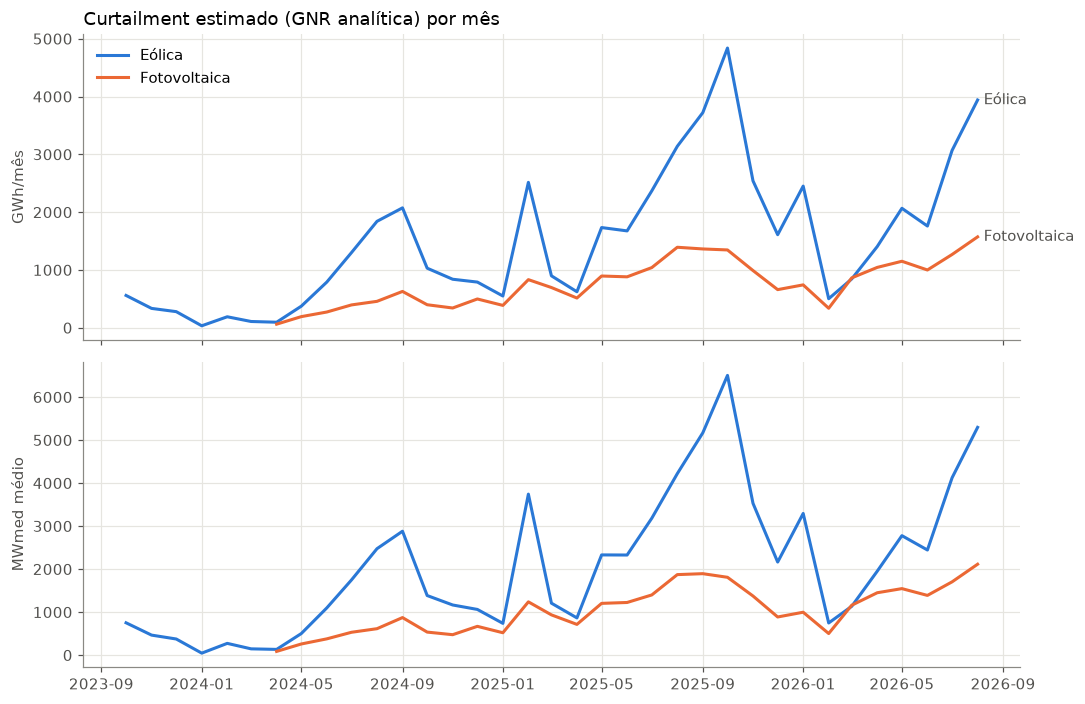

period,eolica,fotovoltaica
str,f64,f64
"""2023-10""","559,168",null
"""2023-11""","334,933",null
"""2023-12""","278,707",null
"""2024-01""","34,133",null
"""2024-02""","189,989",null
"""2024-03""","108,400",null
"""2024-04""","95,747","62,054"
"""2024-05""","373,177","192,509"
"""2024-06""","790,241","272,192"


In [5]:
mensal = (
    df("monthly")
    .with_columns(
        pl.col("period").str.to_date("%Y-%m").alias("mes"),
        pl.col("period")
        .map_elements(
            lambda p: calendar.monthrange(int(p[:4]), int(p[5:]))[1] * 24, return_dtype=pl.Int64
        )
        .alias("horas"),
    )
    .with_columns(
        (pl.col("mwh") / 1000).alias("gwh"),
        (pl.col("mwh") / pl.col("horas")).alias("mwmed_medio"),
        (pl.col("positive") / pl.col("rows")).alias("incidencia"),
    )
)
meta(
    "Gráfico 1: energia e volume médio mensal por fonte",
    SNAPSHOT,
    "out/2023–ago/2026 (fotovoltaica desde abr/2024)",
    "GWh por mês (painel superior); MWmed médio agregado no mês (painel inferior)",
    "todas as entidades presentes no mês; volumes indeterminados (21 intervalos eólicos em 2026) "
    "fora da soma",
    "GWh = Σ energia_mwh / 1000; MWmed médio = Σ energia_mwh / horas do mês",
    "a cobertura de entidades cresce com o tempo (ver painel fixo, seção 12); estimativa "
    "provisória; não é liquidação CCEE",
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for fonte, cor in COR_FONTE.items():
    s = mensal.filter(pl.col("fonte") == fonte).sort("mes")
    axes[0].plot(s["mes"], s["gwh"], color=cor, label=FONTE[fonte])
    axes[1].plot(s["mes"], s["mwmed_medio"], color=cor, label=FONTE[fonte])
    last = s.tail(1)
    axes[0].annotate(
        FONTE[fonte],
        (last["mes"][0], last["gwh"][0]),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        color="#52514e",
    )
axes[0].set_ylabel("GWh/mês")
axes[1].set_ylabel("MWmed médio")
axes[0].set_title("Curtailment estimado (GNR analítica) por mês", loc="left")
axes[0].legend(loc="upper left")
fig.tight_layout()
plt.show()
mensal.select("fonte", "period", "rows", "positive", "incidencia", "gwh", "mwmed_medio").pivot(
    on="fonte", index="period", values="gwh"
).sort("period")

In [6]:
meta(
    "Tabela 2: totais anuais com cobertura explícita",
    SNAPSHOT,
    "anos civis, incompletos nas bordas",
    "TWh; contagem de intervalos",
    "nenhum",
    "meses_cobertos = meses com linhas; TWh = Σ energia_mwh / 10⁶",
    "anos com meses_cobertos < 12 não devem ser comparados como totais anuais",
)
cobertura = mensal.group_by(
    "fonte", pl.col("period").str.slice(0, 4).cast(pl.Int64).alias("year")
).agg(pl.len().alias("meses_cobertos"))
anual = (
    df("annual")
    .join(cobertura, on=["fonte", "year"])
    .with_columns(
        (pl.col("mwh") / 1e6).alias("twh"),
        (pl.col("positive") / pl.col("rows")).alias("incidencia"),
    )
)
anual.select(
    "fonte",
    "year",
    "meses_cobertos",
    "rows",
    "limited",
    "positive",
    "incidencia",
    "invalid_volume",
    "twh",
).sort("fonte", "year")

**Tabela 2: totais anuais com cobertura explícita**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: anos civis, incompletos nas bordas  
- Unidade: TWh; contagem de intervalos  
- Filtros: nenhum  
- Definição: meses_cobertos = meses com linhas; TWh = Σ energia_mwh / 10⁶  
- Limitações: anos com meses_cobertos < 12 não devem ser comparados como totais anuais

fonte,year,meses_cobertos,rows,limited,positive,incidencia,invalid_volume,twh
str,i64,u32,i64,i64,i64,f64,i64,f64
"""eolica""",2.023,3,678.000,82.484,55.972,"0,083",0,"1,173"
"""eolica""",2.024,12,2.774.736,668.026,457.945,"0,165",0,"9,467"
"""eolica""",2.025,12,2.712.912,1.121.670,959.509,"0,354",0,"26,213"
"""eolica""",2.026,8,1.786.272,684.652,624.873,"0,350",21,"16,036"
"""fotovoltaica""",2.024,9,793.152,132.518,85.822,"0,108",0,"3,245"
"""fotovoltaica""",2.025,12,1.161.120,310.559,247.841,"0,213",0,"10,998"
"""fotovoltaica""",2.026,8,900.528,257.254,210.056,"0,233",0,"7,976"


In [7]:
meta(
    "Tabela 3: mesma janela sazonal (abr–ago) em 2024, 2025 e 2026",
    SNAPSHOT,
    "abr–ago de 2024, 2025 e 2026",
    "TWh; variação percentual contra o ano anterior",
    "todas as entidades presentes na janela (painel aberto)",
    "Σ energia_mwh / 10⁶ na janela; var = ano / ano anterior − 1",
    "a janela é sazonal, não é o ano inteiro; o painel aberto mistura crescimento do "
    "curtailment com "
    "a entrada de novas entidades",
)
janela = (
    df("comparable")
    .group_by("fonte", "year")
    .agg(pl.col("mwh").sum() / 1e6, pl.col("positive").sum())
    .rename({"mwh": "twh"})
    .sort("fonte", "year")
    .with_columns(
        (pl.col("twh") / pl.col("twh").shift(1).over("fonte") - 1).alias("var_vs_ano_anterior")
    )
)
janela

**Tabela 3: mesma janela sazonal (abr–ago) em 2024, 2025 e 2026**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: abr–ago de 2024, 2025 e 2026  
- Unidade: TWh; variação percentual contra o ano anterior  
- Filtros: todas as entidades presentes na janela (painel aberto)  
- Definição: Σ energia_mwh / 10⁶ na janela; var = ano / ano anterior − 1  
- Limitações: a janela é sazonal, não é o ano inteiro; o painel aberto mistura crescimento do curtailment com a entrada de novas entidades

fonte,year,twh,positive,var_vs_ano_anterior
str,i64,f64,i64,f64
"""eolica""",2.024,"4,401",197.139,null
"""eolica""",2.025,"9,539",388.599,"1,168"
"""eolica""",2.026,"12,239",439.796,"0,283"
"""fotovoltaica""",2.024,"1,379",38.454,null
"""fotovoltaica""",2.025,"4,724",109.869,"2,426"
"""fotovoltaica""",2.026,"6,034",150.410,"0,277"


## 4. Qual causa domina e como as causas mudam?

`causa` vem de `cod_razaorestricao` normalizado. Os códigos são `REL` (indisponibilidade
externa), `CNF` (confiabilidade elétrica), `ENE` (razão energética, ou seja, excesso de
oferta) e `PAR` (atendimento a requisitos de parecer de acesso). `DESCONHECIDA` indica
limitação sem código reconhecido.

**Gráfico 2: energia mensal por causa, por fonte**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: out/2023–ago/2026 (fotovoltaica desde abr/2024)  
- Unidade: GWh por mês  
- Filtros: somente intervalos com limitação registrada  
- Definição: barras empilhadas de Σ energia_mwh por causa normalizada  
- Limitações: PAR não aparece no snapshot; DESCONHECIDA é quase invisível (42 intervalos solares); o rótulo é registrado pelo ONS e pode ser revisado

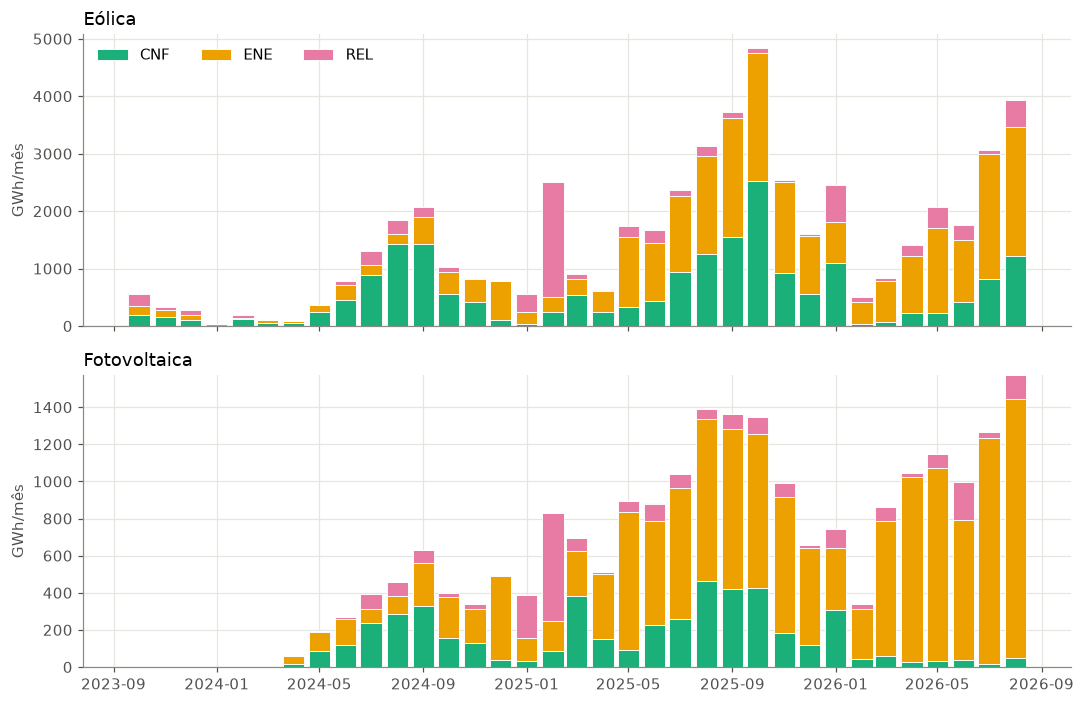

In [8]:
mensal_causa = (
    df("monthly_cause")
    .filter(pl.col("causa").is_not_null())
    .with_columns(
        pl.col("period").str.to_date("%Y-%m").alias("mes"), (pl.col("mwh") / 1000).alias("gwh")
    )
)
meta(
    "Gráfico 2: energia mensal por causa, por fonte",
    SNAPSHOT,
    "out/2023–ago/2026 (fotovoltaica desde abr/2024)",
    "GWh por mês",
    "somente intervalos com limitação registrada",
    "barras empilhadas de Σ energia_mwh por causa normalizada",
    "PAR não aparece no snapshot; DESCONHECIDA é quase invisível (42 intervalos solares); "
    "o rótulo é registrado pelo ONS e pode ser revisado",
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for ax, fonte in zip(axes, COR_FONTE, strict=True):
    s = (
        mensal_causa.filter(pl.col("fonte") == fonte)
        .pivot(on="causa", index="mes", values="gwh")
        .sort("mes")
        .fill_null(0)
    )
    bottom = None
    for causa in [c for c in CAUSAS if c in s.columns]:
        ax.bar(
            s["mes"],
            s[causa],
            width=25,
            bottom=bottom,
            color=COR_CAUSA[causa],
            label=causa,
            edgecolor="white",
            linewidth=0.6,
        )
        bottom = s[causa] if bottom is None else bottom + s[causa]
    ax.set_title(FONTE[fonte], loc="left")
    ax.set_ylabel("GWh/mês")
axes[0].legend(ncols=4, loc="upper left")
fig.tight_layout()
plt.show()

In [9]:
meta(
    "Tabela 4: participação de cada causa na energia anual",
    SNAPSHOT,
    "anos civis, incompletos nas bordas",
    "fração da energia do ano/fonte; TWh",
    "intervalos limitados",
    "participação = Σ energia da causa / Σ energia da fonte no ano",
    "anos incompletos distorcem a sazonalidade; ver também a janela abr–ago",
)
causa_anual = (
    df("annual_cause")
    .filter(pl.col("causa").is_not_null())
    .with_columns(
        (pl.col("mwh") / pl.col("mwh").sum().over("fonte", "year")).alias("participacao"),
        (pl.col("mwh") / 1e6).alias("twh"),
    )
)
causa_anual.pivot(on="causa", index=["fonte", "year"], values="participacao").sort("fonte", "year")

**Tabela 4: participação de cada causa na energia anual**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: anos civis, incompletos nas bordas  
- Unidade: fração da energia do ano/fonte; TWh  
- Filtros: intervalos limitados  
- Definição: participação = Σ energia da causa / Σ energia da fonte no ano  
- Limitações: anos incompletos distorcem a sazonalidade; ver também a janela abr–ago

fonte,year,CNF,ENE,REL,DESCONHECIDA
str,i64,f64,f64,f64,f64
"""eolica""",2.023,"0,377","0,321","0,302",null
"""eolica""",2.024,"0,611","0,294","0,095",null
"""eolica""",2.025,"0,364","0,506","0,130",null
"""eolica""",2.026,"0,258","0,607","0,135",null
"""fotovoltaica""",2.024,"0,430","0,478","0,092",null
"""fotovoltaica""",2.025,"0,259","0,609","0,132","0,000"
"""fotovoltaica""",2.026,"0,071","0,845","0,084","0,000"


In [10]:
meta(
    "Tabela 5: crescimento por causa na mesma janela abr–ago",
    SNAPSHOT,
    "abr–ago de 2024, 2025 e 2026",
    "TWh; múltiplo em relação a 2024",
    "painel aberto; intervalos limitados",
    "multiplo_vs_2024 = TWh do ano / TWh de 2024 na mesma causa e fonte",
    "a base de 2024 é pequena para algumas causas, e múltiplos altos sobre bases pequenas "
    "são sensíveis",
)
causa_janela = (
    df("comparable")
    .filter(pl.col("causa").is_not_null())
    .with_columns((pl.col("mwh") / 1e6).alias("twh"))
    .with_columns(
        (
            pl.col("twh")
            / pl.col("twh").filter(pl.col("year") == 2024).first().over("fonte", "causa")
        ).alias("multiplo_vs_2024")
    )
)
causa_janela.filter(pl.col("causa") != "DESCONHECIDA").pivot(
    on="year", index=["fonte", "causa"], values="multiplo_vs_2024"
).sort("fonte", "causa").join(
    causa_janela.pivot(on="year", index=["fonte", "causa"], values="twh"),
    on=["fonte", "causa"],
    suffix="_twh",
)

**Tabela 5: crescimento por causa na mesma janela abr–ago**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: abr–ago de 2024, 2025 e 2026  
- Unidade: TWh; múltiplo em relação a 2024  
- Filtros: painel aberto; intervalos limitados  
- Definição: multiplo_vs_2024 = TWh do ano / TWh de 2024 na mesma causa e fonte  
- Limitações: a base de 2024 é pequena para algumas causas, e múltiplos altos sobre bases pequenas são sensíveis

fonte,causa,2024,2025,2026,2024_twh,2025_twh,2026_twh
str,str,f64,f64,f64,f64,f64,f64
"""eolica""","""CNF""","1,000","1,040","0,949","3,082","3,204","2,923"
"""eolica""","""ENE""","1,000","7,536","10,688","0,745","5,613","7,960"
"""eolica""","""REL""","1,000","1,257","2,362","0,574","0,722","1,356"
"""fotovoltaica""","""CNF""","1,000","1,601","0,215","0,746","1,194","0,161"
"""fotovoltaica""","""ENE""","1,000","7,051","11,804","0,458","3,227","5,402"
"""fotovoltaica""","""REL""","1,000","1,719","2,684","0,175","0,302","0,471"


## 5. Quais fontes, estados e subsistemas concentram o volume?

Para comparar fontes, estados e subsistemas sem viés de cobertura, usamos **2025**, o único
ano civil completo para as duas fontes.

**Gráfico 3: energia estimada por estado em 2025**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: jan–dez/2025  
- Unidade: TWh  
- Filtros: ano 2025; UF cadastral da entidade (sem mudança de UF observada na auditoria)  
- Definição: Σ energia_mwh por UF e fonte  
- Limitações: a UF é da usina/conjunto, não do ponto onde a restrição elétrica se origina

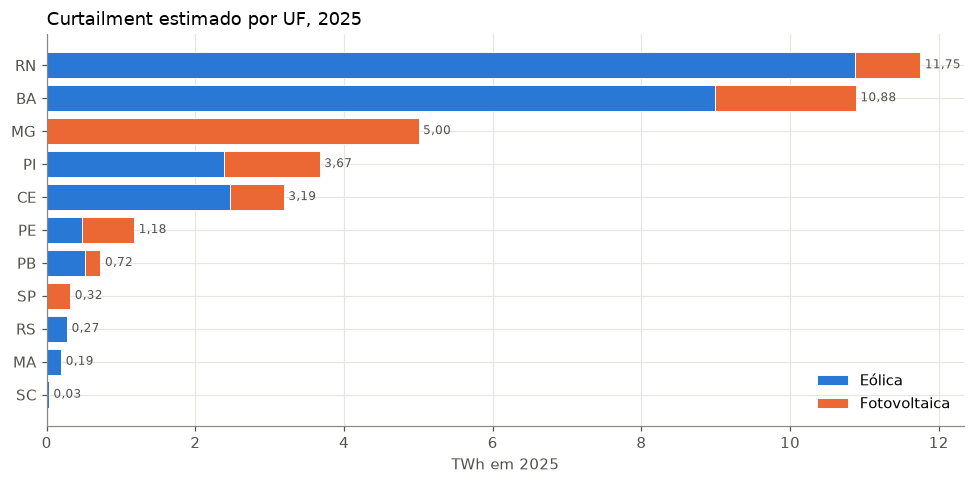

id_estado,twh,participacao
str,f64,f64
"""RN""","11,751","0,316"
"""BA""","10,885","0,293"
"""MG""","5,002","0,134"
"""PI""","3,672","0,099"
"""CE""","3,188","0,086"
"""PE""","1,176","0,032"
"""PB""","0,723","0,019"
"""SP""","0,316","0,009"
"""RS""","0,274","0,007"


In [11]:
estado = df("state").filter(pl.col("year") == 2025).with_columns((pl.col("mwh") / 1e6).alias("twh"))
ordem = estado.group_by("id_estado").agg(pl.col("twh").sum()).sort("twh")["id_estado"].to_list()
meta(
    "Gráfico 3: energia estimada por estado em 2025",
    SNAPSHOT,
    "jan–dez/2025",
    "TWh",
    "ano 2025; UF cadastral da entidade (sem mudança de UF observada na auditoria)",
    "Σ energia_mwh por UF e fonte",
    "a UF é da usina/conjunto, não do ponto onde a restrição elétrica se origina",
)
fig, ax = plt.subplots(figsize=(9, 4.5))
left = pl.Series([0.0] * len(ordem))
for fonte, cor in COR_FONTE.items():
    v = (
        pl.DataFrame({"id_estado": ordem})
        .join(estado.filter(pl.col("fonte") == fonte), on="id_estado", how="left")["twh"]
        .fill_null(0)
    )
    ax.barh(ordem, v, left=left, color=cor, label=FONTE[fonte], edgecolor="white", linewidth=0.6)
    left = left + v
for y, total in enumerate(left):
    ax.annotate(
        f"{total:.2f}".replace(".", ","),
        (total, y),
        xytext=(3, 0),
        textcoords="offset points",
        va="center",
        color="#52514e",
        fontsize=8,
    )
ax.set_xlabel("TWh em 2025")
ax.legend(loc="lower right")
ax.set_title("Curtailment estimado por UF, 2025", loc="left")
fig.tight_layout()
plt.show()
estado_share = (
    estado.group_by("id_estado")
    .agg(pl.col("twh").sum())
    .with_columns((pl.col("twh") / pl.col("twh").sum()).alias("participacao"))
    .sort("twh", descending=True)
)
estado_share

**Gráfico 4: energia estimada por subsistema em 2025**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: jan–dez/2025  
- Unidade: TWh  
- Filtros: ano 2025  
- Definição: Σ energia_mwh por id_subsistema e fonte  
- Limitações: o subsistema é cadastral; o snapshot não liga o corte à restrição física de transmissão

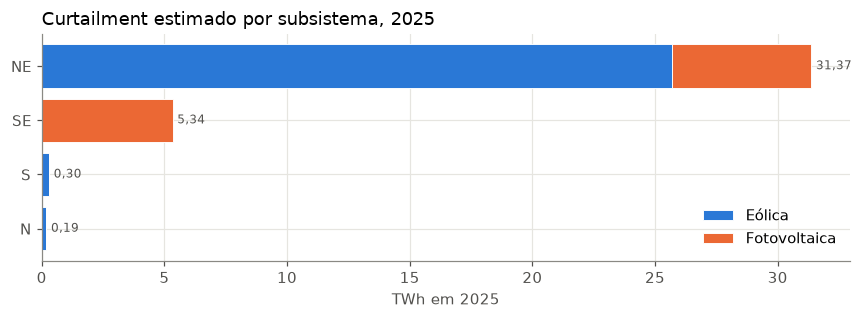

fonte,twh,participacao
str,f64,f64
"""fotovoltaica""","10,998","0,296"
"""eolica""","26,213","0,704"


id_subsistema,eolica,fotovoltaica
str,f64,f64
"""N""","0,195",null
"""NE""","25,694","5,680"
"""S""","0,303",null
"""SE""","0,021","5,318"


In [12]:
sub = (
    df("subsystem").filter(pl.col("year") == 2025).with_columns((pl.col("mwh") / 1e6).alias("twh"))
)
meta(
    "Gráfico 4: energia estimada por subsistema em 2025",
    SNAPSHOT,
    "jan–dez/2025",
    "TWh",
    "ano 2025",
    "Σ energia_mwh por id_subsistema e fonte",
    "o subsistema é cadastral; o snapshot não liga o corte à restrição física de transmissão",
)
subs = sub.group_by("id_subsistema").agg(pl.col("twh").sum()).sort("twh")["id_subsistema"].to_list()
fig, ax = plt.subplots(figsize=(8, 3))
left = pl.Series([0.0] * len(subs))
for fonte, cor in COR_FONTE.items():
    v = (
        pl.DataFrame({"id_subsistema": subs})
        .join(sub.filter(pl.col("fonte") == fonte), on="id_subsistema", how="left")["twh"]
        .fill_null(0)
    )
    ax.barh(subs, v, left=left, color=cor, label=FONTE[fonte], edgecolor="white", linewidth=0.6)
    left = left + v
for y, total in enumerate(left):
    ax.annotate(
        f"{total:.2f}".replace(".", ","),
        (total, y),
        xytext=(3, 0),
        textcoords="offset points",
        va="center",
        color="#52514e",
        fontsize=8,
    )
ax.set_xlabel("TWh em 2025")
ax.legend(loc="lower right")
ax.set_title("Curtailment estimado por subsistema, 2025", loc="left")
fig.tight_layout()
plt.show()
fonte_2025 = (
    sub.group_by("fonte")
    .agg(pl.col("twh").sum())
    .with_columns((pl.col("twh") / pl.col("twh").sum()).alias("participacao"))
)
display(fonte_2025)
sub.pivot(on="fonte", index="id_subsistema", values="twh").sort("id_subsistema")

## 6. Quantas entidades concentram 50%, 80% e 90% do volume?

A unidade é a **entidade da base principal** (`fonte + id_ons`), em sua maioria conjuntos de
usinas: 169 + 11 eólicas e 83 + 4 solares são conjuntos + individuais. Não confundir com
usinas físicas.

**Gráfico 5: concentração acumulada da energia por entidade**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período de cada fonte  
- Unidade: fração acumulada da energia (eixo y) × fração das entidades ordenadas por energia (eixo x)  
- Filtros: entidades com energia estimada positiva  
- Definição: curva de Lorenz invertida: entidades ordenadas da maior para a menor energia  
- Limitações: entidades têm tempos de vida diferentes no snapshot, e parte da concentração reflete entrada recente; conjuntos agregam números diferentes de usinas

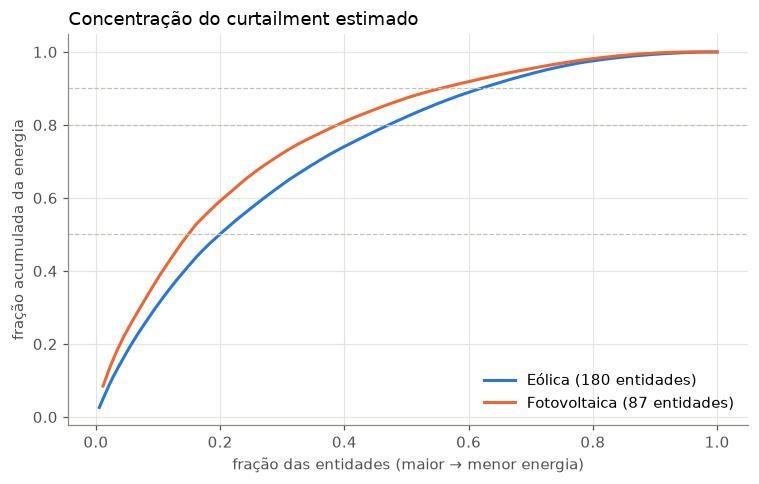

fonte,threshold,entities,positive_entities,share,fracao_entidades
str,f64,i64,i64,f64,f64
"""eolica""","0,500",36,180,"0,501","0,200"
"""eolica""","0,800",85,180,"0,801","0,472"
"""eolica""","0,900",112,180,"0,902","0,622"
"""fotovoltaica""","0,500",13,87,"0,502","0,149"
"""fotovoltaica""","0,800",34,87,"0,802","0,391"
"""fotovoltaica""","0,900",49,87,"0,904","0,563"


In [13]:
entidade = df("entity").filter(pl.col("mwh") > 0)
meta(
    "Gráfico 5: concentração acumulada da energia por entidade",
    SNAPSHOT,
    "todo o período de cada fonte",
    "fração acumulada da energia (eixo y) × fração das entidades ordenadas por energia (eixo x)",
    "entidades com energia estimada positiva",
    "curva de Lorenz invertida: entidades ordenadas da maior para a menor energia",
    "entidades têm tempos de vida diferentes no snapshot, e parte da concentração reflete entrada "
    "recente; conjuntos agregam números diferentes de usinas",
)
fig, ax = plt.subplots(figsize=(7, 4.5))
for fonte, cor in COR_FONTE.items():
    s = entidade.filter(pl.col("fonte") == fonte).sort("mwh", descending=True)
    x = [(i + 1) / s.height for i in range(s.height)]
    y = (s["mwh"].cum_sum() / s["mwh"].sum()).to_list()
    ax.plot(x, y, color=cor, label=f"{FONTE[fonte]} ({s.height} entidades)")
for lvl in (0.5, 0.8, 0.9):
    ax.axhline(lvl, color="#c3c2b7", linewidth=0.8, linestyle="--")
ax.set_xlabel("fração das entidades (maior → menor energia)")
ax.set_ylabel("fração acumulada da energia")
ax.legend(loc="lower right")
ax.set_title("Concentração do curtailment estimado", loc="left")
fig.tight_layout()
plt.show()
concentracao = pl.DataFrame(T["concentration"]).with_columns(
    (pl.col("entities") / pl.col("positive_entities")).alias("fracao_entidades")
)
concentracao

In [14]:
meta(
    "Tabela 6: dez entidades com maior energia estimada",
    SNAPSHOT,
    "todo o período",
    "GWh; fração da energia da fonte",
    "nenhum",
    "Σ energia_mwh por fonte + id_ons",
    "nomes podem mudar ao longo do tempo (mostramos todos); não são usinas individuais",
)
top = (
    df("entity")
    .join(
        df("entity_metadata").select("fonte", "id_ons", "names", "states", "start", "end"),
        on=["fonte", "id_ons"],
    )
    .with_columns(
        (pl.col("mwh") / pl.col("mwh").sum().over("fonte")).alias("fracao_fonte"),
        (pl.col("mwh") / 1000).alias("gwh"),
    )
    .sort("mwh", descending=True)
    .head(10)
)
top.select("fonte", "id_ons", "names", "states", "start", "end", "positive", "gwh", "fracao_fonte")

**Tabela 6: dez entidades com maior energia estimada**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período  
- Unidade: GWh; fração da energia da fonte  
- Filtros: nenhum  
- Definição: Σ energia_mwh por fonte + id_ons  
- Limitações: nomes podem mudar ao longo do tempo (mostramos todos); não são usinas individuais

fonte,id_ons,names,states,start,end,positive,gwh,fracao_fonte
str,str,str,str,datetime[μs],datetime[μs],i64,f64,f64
"""fotovoltaica""","""CJU_MGJAN""","""CONJ. JANAÚBA""","""MG""",2024-04-01 00:00:00,2026-08-31 23:30:00,9.511,"1.884,530","0,085"
"""eolica""","""CJU_RNCAJ1""","""CONJ. CAJU""","""RN""",2023-10-01 00:00:00,2026-08-31 23:30:00,18.554,"1.383,278","0,026"
"""fotovoltaica""","""CJU_MGARN""","""CONJ. ARINOS 2 500 KV""","""MG""",2024-04-30 00:00:00,2026-08-31 23:30:00,7.679,"1.189,395","0,054"
"""eolica""","""CJU_RNRDV""","""CONJ. RIO DO VENTO""","""RN""",2023-10-01 00:00:00,2026-08-31 23:30:00,16.993,"1.180,041","0,022"
"""eolica""","""CJU_RNEMVD""","""CONJ. MONTE VERDE""","""RN""",2023-10-01 00:00:00,2026-08-31 23:30:00,17.954,"1.122,068","0,021"
"""eolica""","""CJU_RNSAG""","""CONJ. SANTO AGOSTINHO""","""RN""",2023-10-01 00:00:00,2026-08-31 23:30:00,21.521,"1.121,095","0,021"
"""eolica""","""CJU_RNRVE""","""CONJ. RIO DO VENTO EXPANSÃO""","""RN""",2023-10-01 00:00:00,2026-08-31 23:30:00,15.498,"1.020,247","0,019"
"""fotovoltaica""","""CJU_MGVST1""","""CONJ. VISTA ALEGRE - JANAÚBA""","""MG""",2024-10-09 00:00:00,2026-08-31 23:30:00,8.286,"1.016,178","0,046"
"""eolica""","""CJU_BALRA""","""CONJ. LARANJEIRAS""","""BA""",2023-10-01 00:00:00,2026-08-31 23:30:00,14.633,"942,509","0,018"


## 7. Quais horários e meses têm maior incidência e volume?

Os horários estão **como publicados**. O timestamp não informa o fuso nem se marca o início ou
o fim do patamar; perfis horários devem ser lidos com essa ressalva.

**Gráfico 6: incidência e energia por hora do dia**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período de cada fonte  
- Unidade: incidência = fração de intervalos com corte positivo; fração da energia da fonte por hora  
- Filtros: todas as entidades; horas agregam os patamares :00 e :30  
- Definição: incidência = positive / rows; energia = Σ energia_mwh da hora / Σ energia_mwh da fonte  
- Limitações: sem fuso nem convenção início/fim; mistura anos com cobertura diferente

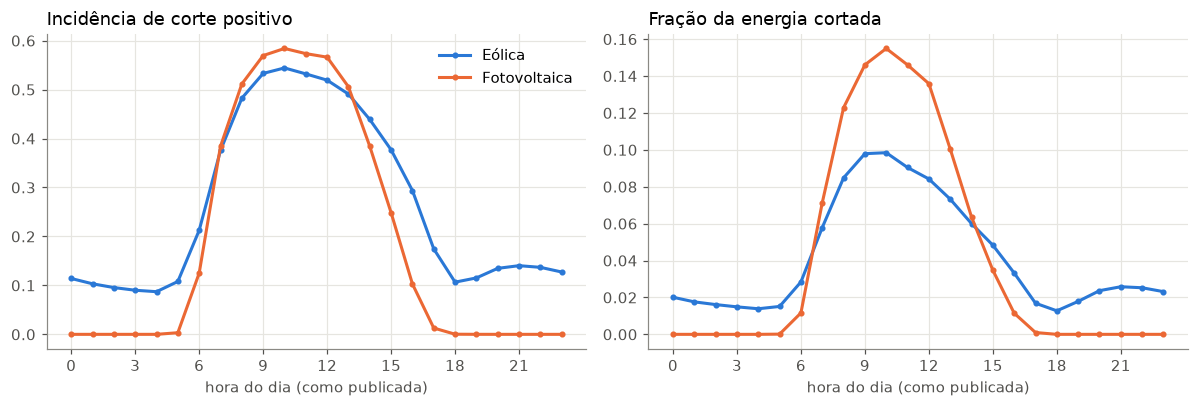

hour,incidencia_eolica,incidencia_fotovoltaica,fracao_energia_eolica,fracao_energia_fotovoltaica
i64,f64,f64,f64,f64
0,"0,114","0,000","0,020","0,000"
1,"0,103","0,000","0,018","0,000"
2,"0,096","0,000","0,016","0,000"
3,"0,090","0,000","0,015","0,000"
4,"0,087","0,000","0,014","0,000"
5,"0,108","0,003","0,015","0,000"
6,"0,212","0,125","0,028","0,012"
7,"0,376","0,384","0,058","0,071"
8,"0,482","0,511","0,085","0,123"


In [15]:
hora = df("hour").with_columns(
    (pl.col("positive") / pl.col("rows")).alias("incidencia"),
    (pl.col("mwh") / pl.col("mwh").sum().over("fonte")).alias("fracao_energia"),
)
meta(
    "Gráfico 6: incidência e energia por hora do dia",
    SNAPSHOT,
    "todo o período de cada fonte",
    "incidência = fração de intervalos com corte positivo; fração da energia da fonte por hora",
    "todas as entidades; horas agregam os patamares :00 e :30",
    "incidência = positive / rows; energia = Σ energia_mwh da hora / Σ energia_mwh da fonte",
    "sem fuso nem convenção início/fim; mistura anos com cobertura diferente",
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for fonte, cor in COR_FONTE.items():
    s = hora.filter(pl.col("fonte") == fonte).sort("hour")
    axes[0].plot(
        s["hour"], s["incidencia"], color=cor, marker="o", markersize=3, label=FONTE[fonte]
    )
    axes[1].plot(
        s["hour"], s["fracao_energia"], color=cor, marker="o", markersize=3, label=FONTE[fonte]
    )
axes[0].set_title("Incidência de corte positivo", loc="left")
axes[1].set_title("Fração da energia cortada", loc="left")
for ax in axes:
    ax.set_xlabel("hora do dia (como publicada)")
    ax.set_xticks(range(0, 24, 3))
axes[0].legend()
fig.tight_layout()
plt.show()
hora.pivot(on="fonte", index="hour", values=["incidencia", "fracao_energia"]).sort("hour")

**Gráfico 7: incidência por mês do ano, uma linha por ano**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: out/2023–ago/2026  
- Unidade: fração de intervalos com corte positivo  
- Filtros: todas as entidades presentes no mês  
- Definição: incidência = positive / rows por fonte, ano e mês  
- Limitações: anos incompletos; em anos diferentes a população de entidades muda

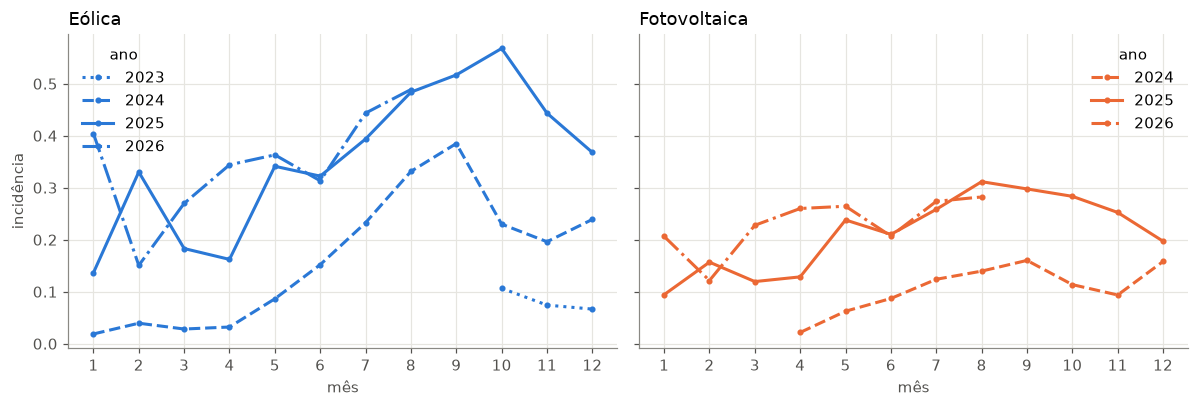

year,month,eolica,fotovoltaica
i64,i64,f64,f64
2.023,10,"0,107",null
2.023,11,"0,074",null
2.023,12,"0,067",null
2.024,1,"0,019",null
2.024,2,"0,039",null
2.024,3,"0,028",null
2.024,4,"0,032","0,022"
2.024,5,"0,086","0,063"
2.024,6,"0,152","0,087"


In [16]:
mes = df("season").with_columns(
    (pl.col("positive") / pl.col("rows")).alias("incidencia"), (pl.col("mwh") / 1000).alias("gwh")
)
meta(
    "Gráfico 7: incidência por mês do ano, uma linha por ano",
    SNAPSHOT,
    "out/2023–ago/2026",
    "fração de intervalos com corte positivo",
    "todas as entidades presentes no mês",
    "incidência = positive / rows por fonte, ano e mês",
    "anos incompletos; em anos diferentes a população de entidades muda",
)
anos = sorted(mes["year"].unique().to_list())
estilo = {2023: ":", 2024: "--", 2025: "-", 2026: "-."}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, fonte in zip(axes, COR_FONTE, strict=True):
    for ano in anos:
        s = mes.filter((pl.col("fonte") == fonte) & (pl.col("year") == ano)).sort("month")
        if s.height:
            ax.plot(
                s["month"],
                s["incidencia"],
                color=COR_FONTE[fonte],
                linestyle=estilo[ano],
                marker="o",
                markersize=3,
                label=str(ano),
            )
    ax.set_title(FONTE[fonte], loc="left")
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("mês")
    ax.legend(title="ano")
axes[0].set_ylabel("incidência")
fig.tight_layout()
plt.show()
mes.pivot(on=["fonte"], index=["year", "month"], values="incidencia").sort("year", "month")

## 8. Os cortes aparecem em episódios recorrentes ou isolados?

Um **episódio** é uma sequência de intervalos consecutivos de 30 min com `corte_positivo` na
mesma entidade. Um intervalo sem corte, com volume desconhecido ou ausente **quebra** o episódio;
lacunas não são ligadas. Episódios nas bordas do snapshot podem estar censurados.

**Gráfico 8: distribuição da duração dos episódios de corte positivo**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período de cada fonte  
- Unidade: número de episódios (escala log) por duração em horas  
- Filtros: episódios observados; durações ≥ 24 h agrupadas na última barra  
- Definição: duração = nº de intervalos consecutivos × 0,5 h  
- Limitações: bordas censuradas; episódios não distinguem causa (uma troca de causa não quebra o episódio)

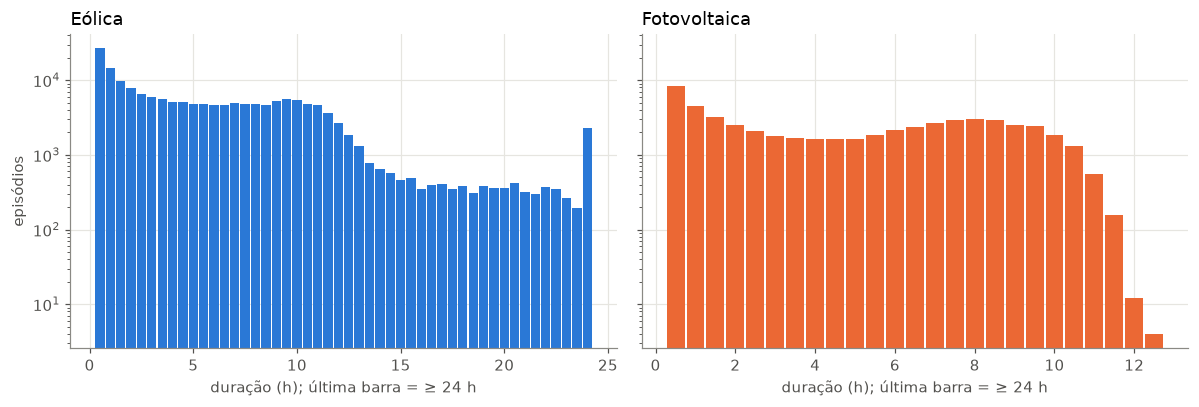

fonte,episodios,intervalos,frac_isolados_30min,frac_ge_4h,frac_intervalos_em_ep_ge_4h,max_intervalos,mediana_intervalos
str,i64,i64,f64,f64,f64,i64,i64
"""eolica""",171.334,2.098.299,"0,156","0,551","0,893",1.214,9
"""fotovoltaica""",55.785,543.719,"0,149","0,569","0,872",25,10


In [17]:
dur = df("episode_durations")
meta(
    "Gráfico 8: distribuição da duração dos episódios de corte positivo",
    SNAPSHOT,
    "todo o período de cada fonte",
    "número de episódios (escala log) por duração em horas",
    "episódios observados; durações ≥ 24 h agrupadas na última barra",
    "duração = nº de intervalos consecutivos × 0,5 h",
    "bordas censuradas; episódios não distinguem causa (uma troca de causa não quebra o episódio)",
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, fonte in zip(axes, COR_FONTE, strict=True):
    s = (
        dur.filter(pl.col("fonte") == fonte)
        .with_columns(pl.min_horizontal(pl.col("slots"), 48).alias("b"))
        .group_by("b")
        .agg(pl.col("episodes").sum())
        .sort("b")
    )
    ax.bar(s["b"] / 2, s["episodes"], width=0.45, color=COR_FONTE[fonte])
    ax.set_yscale("log")
    ax.set_title(FONTE[fonte], loc="left")
    ax.set_xlabel("duração (h); última barra = ≥ 24 h")
axes[0].set_ylabel("episódios")
fig.tight_layout()
plt.show()
resumo_ep = dur.group_by("fonte").agg(
    pl.col("episodes").sum().alias("episodios"),
    (pl.col("episodes") * pl.col("slots")).sum().alias("intervalos"),
    (pl.col("episodes").filter(pl.col("slots") == 1).sum() / pl.col("episodes").sum()).alias(
        "frac_isolados_30min"
    ),
    (pl.col("episodes").filter(pl.col("slots") >= 8).sum() / pl.col("episodes").sum()).alias(
        "frac_ge_4h"
    ),
    (
        (pl.col("episodes") * pl.col("slots")).filter(pl.col("slots") >= 8).sum()
        / (pl.col("episodes") * pl.col("slots")).sum()
    ).alias("frac_intervalos_em_ep_ge_4h"),
    pl.col("slots").max().alias("max_intervalos"),
)
mediana = (
    df("episode_durations")
    .sort("slots")
    .with_columns(
        (pl.col("episodes").cum_sum().over("fonte") / pl.col("episodes").sum().over("fonte")).alias(
            "acum"
        )
    )
    .filter(pl.col("acum") >= 0.5)
    .group_by("fonte")
    .agg(pl.col("slots").first().alias("mediana_intervalos"))
)
resumo_ep = resumo_ep.join(mediana, on="fonte").sort("fonte")
resumo_ep

**Gráfico 9: persistência do corte positivo**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período de cada fonte  
- Unidade: probabilidade empírica  
- Filtros: pares de intervalos observados na mesma entidade com corte conhecido nos dois lados  
- Definição: p_base = P(corte em t); P(corte em t | corte em t−30 min); P(corte em t | corte em t−24 h)  
- Limitações: associação descritiva, não desempenho de modelo; latência de publicação ignorada (ver inventário)

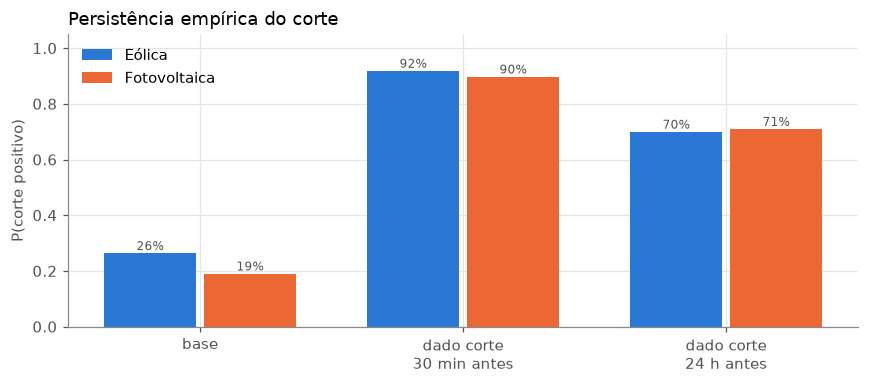

fonte,p_base,p_dado_30min_antes,p_dado_24h_antes,lift_24h,pairs
str,f64,f64,f64,f64,i64
"""eolica""","0,264","0,918","0,700","2,651",7.943.238
"""fotovoltaica""","0,190","0,897","0,709","3,725",2.850.624


In [18]:
dp = df("daily_persistence")
pers = (
    df("persistence")
    .group_by("fonte")
    .agg(
        pl.col("positive_pairs").sum(),
        pl.col("positive_followed_positive").sum(),
        pl.col("next_positive_pairs").sum(),
        pl.col("adjacent_known_pairs").sum(),
    )
)
prob = (
    pers.join(dp, on="fonte")
    .with_columns(
        (pl.col("next_positive_pairs") / pl.col("adjacent_known_pairs")).alias("p_base"),
        (pl.col("positive_followed_positive") / pl.col("positive_pairs")).alias(
            "p_dado_30min_antes"
        ),
        (pl.col("both_positive") / pl.col("previous_positive")).alias("p_dado_24h_antes"),
    )
    .with_columns((pl.col("p_dado_24h_antes") / pl.col("p_base")).alias("lift_24h"))
    .sort("fonte")
)
meta(
    "Gráfico 9: persistência do corte positivo",
    SNAPSHOT,
    "todo o período de cada fonte",
    "probabilidade empírica",
    "pares de intervalos observados na mesma entidade com corte conhecido nos dois lados",
    "p_base = P(corte em t); P(corte em t | corte em t−30 min); P(corte em t | corte em t−24 h)",
    "associação descritiva, não desempenho de modelo; "
    "latência de publicação ignorada (ver inventário)",
)
fig, ax = plt.subplots(figsize=(8, 3.6))
labels = ["base", "dado corte\n30 min antes", "dado corte\n24 h antes"]
w = 0.38
for i, fonte in enumerate(COR_FONTE):
    r = prob.filter(pl.col("fonte") == fonte).row(0, named=True)
    vals = [r["p_base"], r["p_dado_30min_antes"], r["p_dado_24h_antes"]]
    xs = [j + (i - 0.5) * w for j in range(3)]
    ax.bar(xs, vals, width=w - 0.03, color=COR_FONTE[fonte], label=FONTE[fonte])
    for x, v in zip(xs, vals, strict=True):
        ax.annotate(
            f"{v:.0%}",
            (x, v),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#52514e",
        )
ax.set_xticks(range(3), labels)
ax.set_ylabel("P(corte positivo)")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left")
ax.set_title("Persistência empírica do corte", loc="left")
fig.tight_layout()
plt.show()
prob.select("fonte", "p_base", "p_dado_30min_antes", "p_dado_24h_antes", "lift_24h", "pairs")

In [19]:
meta(
    "Tabela 7: entidades com persistência e volume suficientes para justificar antecipação",
    SNAPSHOT,
    "todo o período",
    "contagem de entidades; fração da energia da fonte",
    "critério descritivo fixado antes da contagem: ≥ 500 intervalos de corte positivo e "
    "P(corte em t+30 min | corte em t) ≥ 0,8",
    "persistência por entidade = positive_followed_positive / positive_pairs",
    "critério exploratório, não seleção para backtest; usa dados de todo o período (retrospectivo)",
)
pe = (
    df("persistence")
    .with_columns(
        (pl.col("positive_followed_positive") / pl.col("positive_pairs")).alias("persistencia")
    )
    .join(df("entity").select("fonte", "id_ons", "mwh"), on=["fonte", "id_ons"])
)
pe = pe.with_columns((pl.col("mwh") / pl.col("mwh").sum().over("fonte")).alias("fracao_energia"))
elegivel = (pl.col("positive_pairs") >= 500) & (pl.col("persistencia") >= 0.8)
persistentes = (
    pe.group_by("fonte")
    .agg(
        pl.len().alias("entidades"),
        elegivel.sum().alias("entidades_persistentes"),
        pl.col("fracao_energia").filter(elegivel).sum().alias("fracao_energia_persistentes"),
        pl.col("persistencia").median().alias("mediana_persistencia"),
    )
    .sort("fonte")
)
persistentes

**Tabela 7: entidades com persistência e volume suficientes para justificar antecipação**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período  
- Unidade: contagem de entidades; fração da energia da fonte  
- Filtros: critério descritivo fixado antes da contagem: ≥ 500 intervalos de corte positivo e P(corte em t+30 min | corte em t) ≥ 0,8  
- Definição: persistência por entidade = positive_followed_positive / positive_pairs  
- Limitações: critério exploratório, não seleção para backtest; usa dados de todo o período (retrospectivo)

fonte,entidades,entidades_persistentes,fracao_energia_persistentes,mediana_persistencia
str,u32,u32,f64,f64
"""eolica""",180,175,"1,000","0,918"
"""fotovoltaica""",87,80,"0,998","0,898"


## 9. Qual é a cobertura dos rótulos de causa e origem?

**Gráfico 10: cobertura e composição dos rótulos de causa e origem**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: out/2023–ago/2026  
- Unidade: fração dos intervalos com limitação registrada  
- Filtros: somente intervalos com limitação registrada (fora dela o rótulo é estruturalmente nulo)  
- Definição: cobertura = limitados com código válido / limitados; frac_SIS = limitados com origem SIS / limitados  
- Limitações: rótulo registrado pelo ONS, e não validado por especialista; pode ser revisado em pós-operação

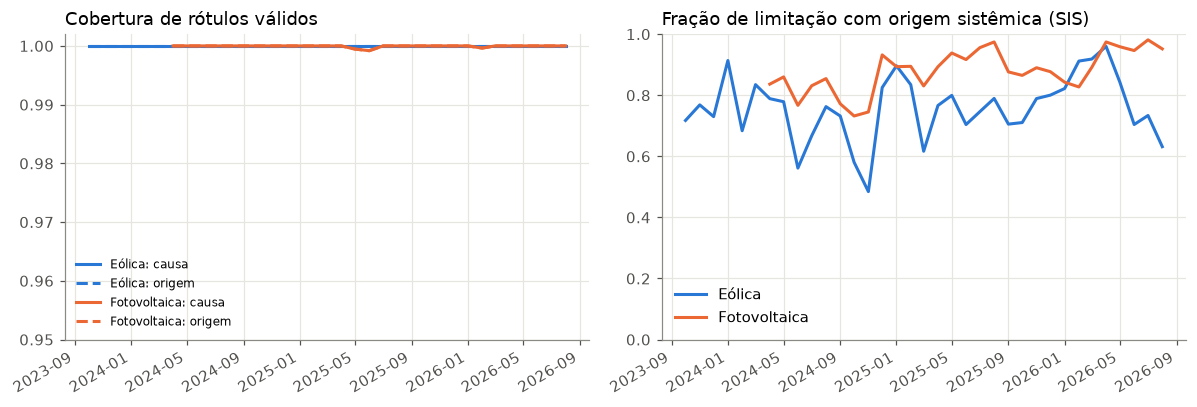

fonte,limitados,causa_desconhecida,origem_desconhecida
str,i64,i64,i64
"""eolica""",2.556.832,0,0
"""fotovoltaica""",700.331,42,42


fonte,causa,origem,rows,twh
str,str,str,i64,f64
"""eolica""","""CNF""","""LOC""",599.123,"11,611"
"""eolica""","""CNF""","""SIS""",455.137,"8,294"
"""eolica""","""ENE""","""SIS""",1.288.851,"26,166"
"""eolica""","""REL""","""LOC""",38.363,"1,015"
"""eolica""","""REL""","""SIS""",175.358,"5,803"
"""fotovoltaica""","""CNF""","""LOC""",59.051,"1,582"
"""fotovoltaica""","""CNF""","""SIS""",108.225,"3,225"
"""fotovoltaica""","""DESCONHECIDA""","""DESCONHECIDA""",42,"0,001"
"""fotovoltaica""","""ENE""","""SIS""",483.137,"14,991"


In [20]:
rot = df("label_coverage").filter(pl.col("causa").is_not_null())
cov = (
    rot.group_by("fonte", "period")
    .agg(
        pl.col("rows").sum().alias("limitados"),
        pl.col("rows").filter(pl.col("causa") != "DESCONHECIDA").sum().alias("causa_conhecida"),
        pl.col("rows").filter(pl.col("origem") != "DESCONHECIDA").sum().alias("origem_conhecida"),
        pl.col("rows").filter(pl.col("origem") == "LOC").sum().alias("LOC"),
        pl.col("rows").filter(pl.col("origem") == "SIS").sum().alias("SIS"),
    )
    .with_columns(
        (pl.col("causa_conhecida") / pl.col("limitados")).alias("cobertura_causa"),
        (pl.col("origem_conhecida") / pl.col("limitados")).alias("cobertura_origem"),
        (pl.col("SIS") / pl.col("limitados")).alias("frac_SIS"),
        pl.col("period").str.to_date("%Y-%m").alias("mes"),
    )
    .sort("fonte", "period")
)
meta(
    "Gráfico 10: cobertura e composição dos rótulos de causa e origem",
    SNAPSHOT,
    "out/2023–ago/2026",
    "fração dos intervalos com limitação registrada",
    "somente intervalos com limitação registrada (fora dela o rótulo é estruturalmente nulo)",
    "cobertura = limitados com código válido / limitados; "
    "frac_SIS = limitados com origem SIS / limitados",
    "rótulo registrado pelo ONS, e não validado por especialista; "
    "pode ser revisado em pós-operação",
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for fonte, cor in COR_FONTE.items():
    s = cov.filter(pl.col("fonte") == fonte)
    axes[0].plot(s["mes"], s["cobertura_causa"], color=cor, label=f"{FONTE[fonte]}: causa")
    axes[0].plot(
        s["mes"], s["cobertura_origem"], color=cor, linestyle="--", label=f"{FONTE[fonte]}: origem"
    )
    axes[1].plot(s["mes"], s["frac_SIS"], color=cor, label=FONTE[fonte])
axes[0].set_ylim(0.95, 1.002)
axes[0].set_title("Cobertura de rótulos válidos", loc="left")
axes[1].set_ylim(0, 1)
axes[1].set_title("Fração de limitação com origem sistêmica (SIS)", loc="left")
axes[0].legend(fontsize=8)
axes[1].legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
cobertura_total = (
    rot.group_by("fonte")
    .agg(
        pl.col("rows").sum().alias("limitados"),
        pl.col("rows").filter(pl.col("causa") == "DESCONHECIDA").sum().alias("causa_desconhecida"),
        pl.col("rows")
        .filter(pl.col("origem") == "DESCONHECIDA")
        .sum()
        .alias("origem_desconhecida"),
    )
    .sort("fonte")
)
display(cobertura_total)
rot.group_by("fonte", "causa", "origem").agg(
    pl.col("rows").sum(), (pl.col("mwh").sum() / 1e6).alias("twh")
).sort("fonte", "causa", "origem")

## 10. Diferenças entre eólica e fotovoltaica

**Gráfico 11: comparação eólica × fotovoltaica em métricas normalizadas**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: todo o período de cada fonte; participação de ENE em 2025  
- Unidade: frações (0–1)  
- Filtros: nenhum além dos indicados em cada métrica  
- Definição: cada barra é uma métrica adimensional já definida nas seções anteriores  
- Limitações: períodos de cobertura diferentes (a fotovoltaica começa em abr/2024); frações não medem volume absoluto

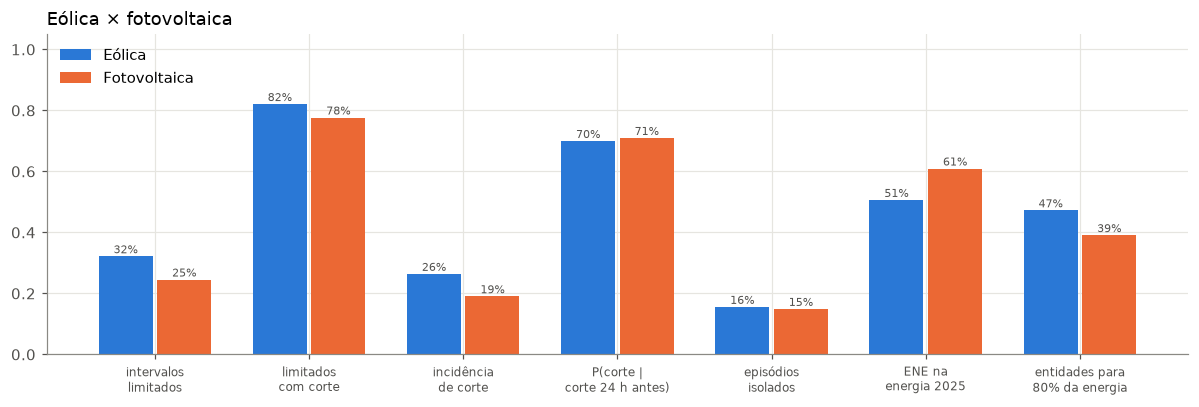

fonte,pct_limitado,pct_limitado_com_corte,pct_limitado_sem_volume,p_base,p_dado_30min_antes,p_dado_24h_antes,mediana_intervalos,frac_isolados_30min,max_intervalos,frac_ENE_2025,frac_entidades_80pct
str,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64
"""eolica""","0,322","0,821","0,179","0,264","0,918","0,700",9,"0,156",1.214,"0,506","0,472"
"""fotovoltaica""","0,245","0,776","0,224","0,190","0,897","0,709",10,"0,149",25,"0,609","0,391"


In [21]:
lado = (
    qualidade.select("fonte", "pct_limitado", "pct_limitado_com_corte", "pct_limitado_sem_volume")
    .join(prob.select("fonte", "p_base", "p_dado_30min_antes", "p_dado_24h_antes"), on="fonte")
    .join(
        resumo_ep.select("fonte", "mediana_intervalos", "frac_isolados_30min", "max_intervalos"),
        on="fonte",
    )
    .join(
        causa_anual.filter((pl.col("year") == 2025) & (pl.col("causa") == "ENE")).select(
            "fonte", pl.col("participacao").alias("frac_ENE_2025")
        ),
        on="fonte",
    )
    .join(
        concentracao.filter(pl.col("threshold") == 0.8).select(
            "fonte", pl.col("fracao_entidades").alias("frac_entidades_80pct")
        ),
        on="fonte",
    )
)
meta(
    "Gráfico 11: comparação eólica × fotovoltaica em métricas normalizadas",
    SNAPSHOT,
    "todo o período de cada fonte; participação de ENE em 2025",
    "frações (0–1)",
    "nenhum além dos indicados em cada métrica",
    "cada barra é uma métrica adimensional já definida nas seções anteriores",
    "períodos de cobertura diferentes (a fotovoltaica começa em abr/2024); frações não "
    "medem volume absoluto",
)
metricas = [
    "pct_limitado",
    "pct_limitado_com_corte",
    "p_base",
    "p_dado_24h_antes",
    "frac_isolados_30min",
    "frac_ENE_2025",
    "frac_entidades_80pct",
]
nomes = [
    "intervalos\nlimitados",
    "limitados\ncom corte",
    "incidência\nde corte",
    "P(corte |\ncorte 24 h antes)",
    "episódios\nisolados",
    "ENE na\nenergia 2025",
    "entidades para\n80% da energia",
]
fig, ax = plt.subplots(figsize=(11, 3.8))
for i, fonte in enumerate(COR_FONTE):
    r = lado.filter(pl.col("fonte") == fonte).row(0, named=True)
    xs = [j + (i - 0.5) * w for j in range(len(metricas))]
    ax.bar(xs, [r[m] for m in metricas], width=w - 0.03, color=COR_FONTE[fonte], label=FONTE[fonte])
    for x, m in zip(xs, metricas, strict=True):
        ax.annotate(
            f"{r[m]:.0%}",
            (x, r[m]),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            fontsize=7,
            color="#52514e",
        )
ax.set_xticks(range(len(metricas)), nomes, fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left")
ax.set_title("Eólica × fotovoltaica", loc="left")
fig.tight_layout()
plt.show()
lado

## 11. Impacto de usar todas as entidades × painel fixo

O número de entidades muda ao longo do tempo. Parte do crescimento do painel aberto pode vir
de **novas entidades**, e não de mais corte nas mesmas. O painel fixo foi definido **a priori** em
`curtamap.eda`: entidades com 100% das 7.344 janelas de abr–ago em cada um dos anos 2024,
2025 e 2026, e volume válido em todas. É um painel retrospectivo de sensibilidade e não serve
para selecionar entidades para o backtest.

**Gráfico 12: painel aberto × painel fixo, mesma janela abr–ago**  
- Fonte: Snapshot ONS do Hackathon, bases principais eólica + fotovoltaica  
- Período: abr–ago de 2024, 2025 e 2026  
- Unidade: TWh  
- Filtros: painel fixo: 135 entidades eólicas e 50 solares, com cobertura completa e volume válido nas três janelas  
- Definição: Σ energia_mwh na janela  
- Limitações: painel sobrevivente (viés de sobrevivência): exclui entidades novas e as com dados inválidos

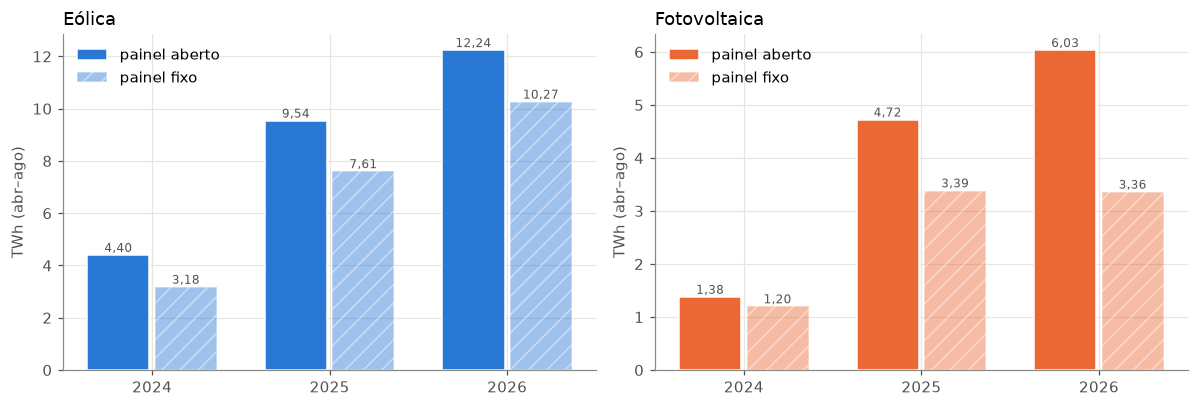

fonte,painel,2024,2025,2026,2024_var,2025_var,2026_var
str,str,f64,f64,f64,f64,f64,f64
"""eolica""","""painel aberto""","4,401","9,539","12,239",null,"1,168","0,283"
"""eolica""","""painel fixo""","3,181","7,606","10,265",null,"1,391","0,350"
"""fotovoltaica""","""painel aberto""","1,379","4,724","6,034",null,"2,426","0,277"
"""fotovoltaica""","""painel fixo""","1,201","3,386","3,361",null,"1,821","-0,008"


In [22]:
aberto = (
    df("comparable")
    .group_by("fonte", "year")
    .agg((pl.col("mwh").sum() / 1e6).alias("twh"))
    .with_columns(pl.lit("painel aberto").alias("painel"))
)
fixo = (
    df("fixed_panel")
    .group_by("fonte", "year")
    .agg((pl.col("mwh").sum() / 1e6).alias("twh"))
    .with_columns(pl.lit("painel fixo").alias("painel"))
)
paineis = (
    pl.concat([aberto, fixo])
    .sort("fonte", "painel", "year")
    .with_columns(
        (pl.col("twh") / pl.col("twh").shift(1).over("fonte", "painel") - 1).alias(
            "var_vs_ano_anterior"
        )
    )
)
n_painel = {r["fonte"]: r["entities"] for r in T["panel_entities"]}
meta(
    "Gráfico 12: painel aberto × painel fixo, mesma janela abr–ago",
    SNAPSHOT,
    "abr–ago de 2024, 2025 e 2026",
    "TWh",
    f"painel fixo: {n_painel['eolica']} entidades eólicas e {n_painel['fotovoltaica']} solares, "
    "com cobertura completa e volume válido nas três janelas",
    "Σ energia_mwh na janela",
    "painel sobrevivente (viés de sobrevivência): exclui entidades novas e as com dados inválidos",
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, fonte in zip(axes, COR_FONTE, strict=True):
    for i, (painel, alpha, hatch) in enumerate(
        [("painel aberto", 1.0, None), ("painel fixo", 0.45, "//")]
    ):
        s = paineis.filter((pl.col("fonte") == fonte) & (pl.col("painel") == painel)).sort("year")
        xs = [y + (i - 0.5) * w for y in s["year"]]
        ax.bar(
            xs,
            s["twh"],
            width=w - 0.03,
            color=COR_FONTE[fonte],
            alpha=alpha,
            hatch=hatch,
            edgecolor="white",
            label=painel,
        )
        for x, v in zip(xs, s["twh"], strict=True):
            ax.annotate(
                f"{v:.2f}".replace(".", ","),
                (x, v),
                xytext=(0, 2),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="#52514e",
            )
    ax.set_xticks([2024, 2025, 2026])
    ax.set_title(FONTE[fonte], loc="left")
    ax.set_ylabel("TWh (abr–ago)")
    ax.legend(loc="upper left")
fig.tight_layout()
plt.show()
paineis.pivot(on="year", index=["fonte", "painel"], values="twh").join(
    paineis.pivot(on="year", index=["fonte", "painel"], values="var_vs_ano_anterior"),
    on=["fonte", "painel"],
    suffix="_var",
).sort("fonte", "painel")

## 12. Validação contra a publicação atual do ONS

Resumo de `docs/reports/stage1/official-comparison.json`, gerado por
`python -m curtamap.public_reference` a partir de 64 arquivos mensais atuais do portal de dados
abertos do ONS. As URLs, as datas e os SHA-256 estão em `official-manifest.json`.

In [23]:
fv = OFFICIAL["formula_validation"]
pt = lambda n: f"{n:,}".replace(",", ".")  # noqa: E731
display(
    Markdown(
        f"- GNRa publicada não nula: **{pt(fv['published_nonnull'])}**; "
        f"comparável: {pt(fv['comparable'])}; "
        f"divergências > 0,001 MW: **{fv['different_over_001_mw']}**; "
        f"diferença máxima: {fv['max_difference_mw']:.2e} MW.  \n"
        f"- Intervalos limitados sem GNRa publicada: **{pt(fv['limited_missing_published'])}**."
    )
)
rev = pl.DataFrame(OFFICIAL["revision_check"])
meta(
    "Tabela 8: revisões entre o snapshot e a publicação atual, por fonte e ano",
    "Snapshot do Hackathon × Parquet mensais atuais do ONS (acesso em 19/09/2026)",
    "mesmos meses do snapshot",
    "contagem de intervalos; MWh",
    "junção pela chave fonte + id_ons + din_instante",
    "changed_numeric = geração/limite/referência diferentes; "
    "changed_labels = causa/origem diferentes (NULL e '' são equivalentes); "
    "matched_delta = energia do snapshot − energia recalculada da publicação",
    "diferenças são provisórias: o ONS revisa em pós-operação (last_modified até 19/09/2026)",
)
rev.with_columns(pl.col("period").str.slice(0, 4).alias("ano")).group_by("fonte", "ano").agg(
    pl.len().alias("meses"),
    pl.col("revised").sum().alias("meses_revisados"),
    pl.col("matched").sum(),
    pl.col("only_local").sum(),
    pl.col("only_official").sum(),
    pl.col("changed_numeric").sum(),
    pl.col("changed_labels").sum(),
    pl.col("changed_energy").sum(),
    pl.col("matched_delta_mwh").sum(),
).sort("fonte", "ano")

- GNRa publicada não nula: **3.127.621**; comparável: 3.127.621; divergências > 0,001 MW: **0**; diferença máxima: 2.27e-13 MW.  
- Intervalos limitados sem GNRa publicada: **129.615**.

**Tabela 8: revisões entre o snapshot e a publicação atual, por fonte e ano**  
- Fonte: Snapshot do Hackathon × Parquet mensais atuais do ONS (acesso em 19/09/2026)  
- Período: mesmos meses do snapshot  
- Unidade: contagem de intervalos; MWh  
- Filtros: junção pela chave fonte + id_ons + din_instante  
- Definição: changed_numeric = geração/limite/referência diferentes; changed_labels = causa/origem diferentes (NULL e '' são equivalentes); matched_delta = energia do snapshot − energia recalculada da publicação  
- Limitações: diferenças são provisórias: o ONS revisa em pós-operação (last_modified até 19/09/2026)

fonte,ano,meses,meses_revisados,matched,only_local,only_official,changed_numeric,changed_labels,changed_energy,matched_delta_mwh
str,str,u32,u32,i64,i64,i64,i64,i64,i64,f64
"""eolica""","""2023""",3,3,678.000,0,0,3.405,0,587,"-2.794,033"
"""eolica""","""2024""",12,12,2.774.112,624,624,16.997,39,4.686,"-81.143,548"
"""eolica""","""2025""",12,3,2.712.912,0,0,3.391,0,1.316,"-4.195,861"
"""eolica""","""2026""",8,8,1.786.272,0,0,80.127,58,32.511,"-167.895,247"
"""fotovoltaica""","""2024""",9,1,793.152,0,0,2.071,0,63,"-1.048,883"
"""fotovoltaica""","""2025""",12,12,1.161.120,0,0,5.761,0,3.178,"-2.331,447"
"""fotovoltaica""","""2026""",8,8,900.528,0,0,20.538,76,9.969,"-38.631,173"


In [24]:
meta(
    "Tabela 9: totais por fonte e ano, snapshot × GNRa publicada",
    "Snapshot × publicação atual ONS",
    "anos civis cobertos",
    "MWh; %",
    "nenhum",
    "delta = snapshot − publicação; nulo quando um dos lados tem volume indeterminado",
    "comparação de totais não é reconciliação financeira nem comercial",
)
pl.DataFrame(
    [
        {
            "fonte": r["fonte"],
            "year": r["year"],
            "mwh_snapshot": r["local"].get("mwh"),
            "indeterminados_snapshot": r["local"].get("unknown"),
            "mwh_publicado": r["official"].get("mwh"),
            "sem_gnra_publicada": r["official"].get("unknown"),
            "delta_pct": r["delta_percent"],
            "comparavel": r["totals_comparable"],
        }
        for r in OFFICIAL["comparisons"]["fonte"]
    ]
)

**Tabela 9: totais por fonte e ano, snapshot × GNRa publicada**  
- Fonte: Snapshot × publicação atual ONS  
- Período: anos civis cobertos  
- Unidade: MWh; %  
- Filtros: nenhum  
- Definição: delta = snapshot − publicação; nulo quando um dos lados tem volume indeterminado  
- Limitações: comparação de totais não é reconciliação financeira nem comercial

fonte,year,mwh_snapshot,indeterminados_snapshot,mwh_publicado,sem_gnra_publicada,delta_pct,comparavel
str,i64,f64,i64,f64,i64,f64,bool
"""eolica""",2.023,"1.172.806,899",0,"1.175.600,931",0,"-0,238",true
"""eolica""",2.024,"9.466.916,191",0,"9.548.059,739",0,"-0,850",true
"""eolica""",2.025,"26.212.729,583",0,"26.216.925,444",0,"-0,016",true
"""eolica""",2.026,"16.035.860,072",21,"16.207.486,969",0,null,false
"""fotovoltaica""",2.024,"3.245.111,230",0,"63.103,052",129.615,null,false
"""fotovoltaica""",2.025,"10.998.020,584",0,"11.000.352,031",0,"-0,021",true
"""fotovoltaica""",2.026,"7.976.193,162",0,"8.014.824,335",0,"-0,482",true


## 13. Verificação dos números citados na síntese

Cada número usado no texto abaixo é recalculado aqui. Se os dados ou o código mudarem, esta
célula falha e a narrativa precisa ser revista.

In [25]:
def perto(valor, esperado, tol=0.0015):
    assert abs(valor - esperado) <= tol, (valor, esperado)


def v(frame, col, **filtros):
    expr = pl.lit(True)
    for k, x in filtros.items():
        expr = expr & (pl.col(k) == x)
    return frame.filter(expr)[col].item()


# Comando × corte
perto(v(qualidade, "pct_limitado_sem_volume", fonte="eolica"), 0.179)
perto(v(qualidade, "pct_limitado_sem_volume", fonte="fotovoltaica"), 0.224)
# Crescimento na janela abr–ago, painel aberto e fixo
for fonte, anos in {
    "eolica": [4.401, 9.539, 12.239],
    "fotovoltaica": [1.379, 4.724, 6.034],
}.items():
    for ano, twh in zip([2024, 2025, 2026], anos, strict=True):
        perto(v(janela, "twh", fonte=fonte, year=ano), twh)
for fonte, anos in {
    "eolica": [3.181, 7.606, 10.265],
    "fotovoltaica": [1.201, 3.386, 3.361],
}.items():
    for ano, twh in zip([2024, 2025, 2026], anos, strict=True):
        perto(
            v(paineis.filter(pl.col("painel") == "painel fixo"), "twh", fonte=fonte, year=ano), twh
        )
assert n_painel == {"eolica": 135, "fotovoltaica": 50}
# Causas
perto(v(causa_anual, "participacao", fonte="eolica", year=2024, causa="CNF"), 0.611)
perto(v(causa_anual, "participacao", fonte="eolica", year=2025, causa="ENE"), 0.506)
perto(v(causa_anual, "participacao", fonte="eolica", year=2026, causa="ENE"), 0.607)
perto(v(causa_anual, "participacao", fonte="fotovoltaica", year=2025, causa="ENE"), 0.609)
perto(v(causa_anual, "participacao", fonte="fotovoltaica", year=2026, causa="ENE"), 0.845)
for fonte, anos in {"eolica": [0.745, 5.613, 7.960], "fotovoltaica": [0.458, 3.227, 5.402]}.items():
    for ano, twh in zip([2024, 2025, 2026], anos, strict=True):
        perto(v(causa_janela, "twh", fonte=fonte, year=ano, causa="ENE"), twh)
perto(v(causa_janela, "twh", fonte="eolica", year=2026, causa="CNF"), 2.923)
perto(v(mensal_causa, "gwh", fonte="eolica", period="2025-02", causa="REL"), 2014.843, 0.01)
# Geografia 2025
perto(v(estado_share, "participacao", id_estado="RN"), 0.316)
perto(v(estado_share, "participacao", id_estado="BA"), 0.293)
perto(v(estado_share, "participacao", id_estado="MG"), 0.134)
subs_share = (
    sub.group_by("id_subsistema")
    .agg(pl.col("twh").sum())
    .with_columns(pl.col("twh") / pl.col("twh").sum())
)
perto(v(subs_share, "twh", id_subsistema="NE"), 0.843)
perto(v(fonte_2025, "participacao", fonte="eolica"), 0.704)
perto(v(fonte_2025, "twh", fonte="eolica") + v(fonte_2025, "twh", fonte="fotovoltaica"), 37.211)
# Concentração
assert concentracao.select("fonte", "threshold", "entities").rows() == [
    ("eolica", 0.5, 36),
    ("eolica", 0.8, 85),
    ("eolica", 0.9, 112),
    ("fotovoltaica", 0.5, 13),
    ("fotovoltaica", 0.8, 34),
    ("fotovoltaica", 0.9, 49),
]
# Horário
assert hora.sort("incidencia", descending=True).group_by("fonte", maintain_order=True).first().sort(
    "fonte"
)["hour"].to_list() == [10, 10]
# Episódios e persistência
assert resumo_ep["mediana_intervalos"].to_list() == [9, 10]
perto(v(resumo_ep, "frac_isolados_30min", fonte="eolica"), 0.156)
perto(v(resumo_ep, "frac_isolados_30min", fonte="fotovoltaica"), 0.149)
perto(v(resumo_ep, "frac_intervalos_em_ep_ge_4h", fonte="eolica"), 0.893)
perto(v(resumo_ep, "frac_intervalos_em_ep_ge_4h", fonte="fotovoltaica"), 0.872)
perto(v(prob, "p_base", fonte="eolica"), 0.264)
perto(v(prob, "p_base", fonte="fotovoltaica"), 0.190)
perto(v(prob, "p_dado_30min_antes", fonte="eolica"), 0.918)
perto(v(prob, "p_dado_30min_antes", fonte="fotovoltaica"), 0.897)
perto(v(prob, "p_dado_24h_antes", fonte="eolica"), 0.700)
perto(v(prob, "p_dado_24h_antes", fonte="fotovoltaica"), 0.709)
assert persistentes.select("entidades", "entidades_persistentes").rows() == [(180, 175), (87, 80)]
# Rótulos
assert cobertura_total.select("causa_desconhecida", "origem_desconhecida").rows() == [
    (0, 0),
    (42, 42),
]
# Validação pública
assert (fv["published_nonnull"], fv["different_over_001_mw"], fv["limited_missing_published"]) == (
    3127621,
    0,
    129615,
)
assert (rev.height, int(rev["revised"].sum())) == (64, 47)
"Todos os números citados conferem."

'Todos os números citados conferem.'

## 14. Síntese: respostas às perguntas da Etapa 1

Todos os valores abaixo são **estimativas analíticas** da GNR sobre o snapshot, conferidas na
seção 13. Não são liquidação CCEE, ressarcimento ou valor financeiro.

| Pergunta | Resposta com base nos dados |
|---|---|
| O curtailment cresce? | Sim. Na mesma janela abr–ago, a eólica passa de 4,40 TWh (2024) para 9,54 (2025) e 12,24 (2026). A fotovoltaica passa de 1,38 para 4,72 e 6,03 TWh. |
| O crescimento é só expansão de cobertura? | Na eólica, não: no painel fixo de 135 entidades, o volume vai de 3,18 para 7,61 e 10,27 TWh. Na fotovoltaica, o painel fixo de 50 entidades sobe de 1,20 para 3,39 TWh e fica **estável** em 2026 (3,36). O aumento solar de 2025 para 2026 vem de entidades que não estão no painel fixo. |
| Qual causa domina? | Mudou ao longo do tempo. CNF dominava a eólica em 2024 (61% da energia). ENE passa a dominar em 2025 (eólica 51%, fotovoltaica 61%) e em 2026 até agosto (eólica 61%, fotovoltaica 84%). |
| ENE cresce mais rápido? | Sim. Na janela abr–ago, ENE eólica vai de 0,75 para 5,61 e 7,96 TWh; ENE solar, de 0,46 para 3,23 e 5,40 TWh. CNF eólica fica em cerca de 3 TWh (3,08 → 3,20 → 2,92). |
| Quais fontes concentram o volume? | Em 2025, o único ano completo para ambas, 70% da energia é eólica. O total das duas fontes é de 37,21 TWh. |
| Estados e subsistemas? | Em 2025, RN responde por 32%, BA por 29% e MG (quase só solar) por 13%. O subsistema NE concentra 84%. |
| Quantas entidades concentram 50/80/90%? | Eólica: 36, 85 e 112 de 180 entidades. Fotovoltaica: 13, 34 e 49 de 87. São conjuntos ou usinas da base principal, não usinas físicas. |
| Horários e meses? | O pico de incidência ocorre às 10 h (como publicado) nas duas fontes. A eólica também tem incidência noturna de 9–14%; a solar é nula à noite. Os maiores meses eólicos foram set–out/2025 e ago/2026. |
| Episódios recorrentes ou isolados? | Recorrentes. A mediana é de 9 (eólica) e 10 (fotovoltaica) intervalos, ou seja, 4,5–5 h. Só 15–16% dos episódios duram 30 min, e cerca de 87–89% dos intervalos com corte estão em episódios de 4 h ou mais. |
| Há persistência para antecipar? | Sim, de forma descritiva. P(corte \| corte 24 h antes) é de 70% (eólica) e 71% (solar), contra taxas-base de 26% e 19%. O critério a priori (≥ 500 intervalos, P(t+30 min) ≥ 0,8) aprova 175/180 e 80/87 entidades. Ele **não discrimina**, então a persistência é disseminada e não restrita a poucas entidades. |
| Eólica × fotovoltaica? | Perfis diferentes: a solar concentra-se no meio do dia, com episódios de no máximo 12,5 h. A eólica tem cauda noturna e episódios de até 607 h. A solar é mais concentrada em poucas entidades e mais dominada por ENE. |
| Cobertura dos rótulos? | Praticamente completa: a eólica tem 0 limitações sem causa ou origem válida, e a solar tem 42 em 700.331. PAR não aparece. A origem é majoritariamente SIS (75% dos intervalos eólicos limitados; 90% dos solares). |
| Painel completo × fixo? | O painel aberto amplifica o crescimento solar recente. A conclusão “ENE cresce” se mantém nos dois, mas a magnitude do crescimento solar depende do painel. |

### Fatos observados

- 18% (eólica) e 22% (solar) dos intervalos com **limitação registrada têm volume zero**.
  Comando de limitação e corte efetivo são alvos diferentes.
- Em fev/2025 houve um pico isolado de **REL** eólico (2,01 TWh no mês), visível no Gráfico 2.
- A fórmula GNRa reproduz 3.127.621 valores publicados pelo ONS, sem divergência acima de
  0,001 MW. Porém, 47 dos 64 meses do snapshot foram revisados na publicação atual
  (seção 12), e 129.615 intervalos solares limitados de 2024 não têm GNRa publicada.

### Interpretações

- O problema cresceu rápido e mudou de natureza. O corte deixou de ser predominantemente
  elétrico/local (CNF) e passou a ser energético/sistêmico (ENE, SIS). Para o gerador, isso
  significa perdas mais frequentes, longas e comuns a muitas usinas ao mesmo tempo.
- A alta persistência intradiária e diária indica que **baselines ingênuos serão fortes**. Um
  modelo só agrega valor se superar “mesmo horário do dia anterior”, sobretudo no início e
  no fim de episódios.

### Hipóteses (não verificadas nesta etapa)

- O crescimento de ENE está associado à expansão da oferta renovável e ao excedente no
  meio do dia. Os dados não medem a causa física.
- O pico REL de fev/2025 seria um evento de indisponibilidade externa de grande escala.
  Isso requer confirmação em fontes do ONS.
- Uma previsão de ENE depende mais de sinais sistêmicos (carga, oferta agregada, meteorologia
  prevista) do que do histórico da própria usina.

### Decisões para a Etapa 2

- Manter **dois alvos de ocorrência** (`restricao_registrada` e `corte_positivo`) e
  condicionar o volume ao corte positivo.
- Tratar a unidade como **entidade da base principal** (conjunto ou usina), com a chave
  `fonte + id_ons`.
- Avaliar sempre por fonte e por causa. Relatar o painel fixo junto do aberto.
- Obrigatórios: os baselines “último valor” e “mesmo horário do dia anterior”, com latência
  declarada (ver `docs/feature-inventory.md`).

### Limitações

- O timestamp não tem fuso nem convenção de início/fim. Perfis horários valem “como publicados”.
- Anos incompletos nas bordas; a fotovoltaica começa em abr/2024.
- O snapshot difere da publicação atual em 47 meses. Os totais são provisórios.
- 21 volumes eólicos de 2026 estão indeterminados por entradas negativas (3.732 MWh na variante
  bruta).
- Nada aqui é desempenho preditivo. Persistência descritiva ≠ acurácia de modelo.
- Detail (vento/irradiância verificados) não foi usado: tem duplicatas, lacunas e extremos, e
  não é previsão D+1.

### Referências externas (não reproduzidas aqui)

- **Externo:** o Caderno do Hackathon cita um estudo da Volt Robotics segundo o qual cerca de
  20% da geração potencial eólica e solar foi cortada em 2025, com 4.021 MWmed e cerca de
  R$ 6,5 bilhões. Esta EDA **não** reproduz esses números: os denominadores, a métrica e o escopo
  diferem. Nosso total de 2025 é de 37,21 TWh de GNR analítica, cerca de 4.248 MWmed médios no
  ano, mas a proximidade com 4.021 MWmed não é validação.

### Próximos passos (Etapa 2)

1. Congelar cortes temporais e o protocolo as-of, com cenários de latência de publicação.
2. Implementar os baselines e as métricas (PR-AUC/recall, MAE/WAPE, macro-F1) por fonte e causa.
3. Buscar sinais sistêmicos disponíveis ex-ante, sobretudo para ENE.
4. Decidir o tratamento das 21 linhas com entradas negativas e das entidades renomeadas
   (`BA4ECLA` → `CJU_BA4ECLA`).